In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.patches import Rectangle
import cmocean

from lo_tools import plotting_functions as pfun

In [ ]:
years = [2015, 2016, 2017]
keys = ["obs", "cas7_t1_x11ab", "ssc"]

data_list = []
for yy in years:
    fn = f"./combined_bottle_{yy}_cas7_t1_x11ab_ssc.pkl"
    data_list.append(pd.read_pickle(fn))

# concatenate for each key
data_all = {}
for k in keys:
    data_all[k] = pd.concat([d[k] for d in data_list], ignore_index=True)

print(data_all.keys())
print("obs:", data_all["obs"].shape)
print("cas7_t1_x11ab:", data_all["cas7_t1_x11ab"].shape)
print("ssc:", data_all["ssc"].shape)

dict_keys(['obs', 'cas7_t1_x11ab', 'ssc'])
obs: (15060, 19)
cas7_t1_x11ab: (15060, 16)
ssc: (15807, 16)


In [3]:
print(list(data_all.keys()))

['obs', 'cas7_t1_x11ab', 'ssc']


In [4]:
print(data_all["obs"].columns)
print(data_all["cas7_t1_x11ab"].columns)
print(data_all["ssc"].columns)

Index(['cid', 'lon', 'lat', 'time', 'z', 'SA', 'CT', 'DO', 'NO3', 'Chl',
       'name', 'cruise', 'source', 'NH4', 'PO4 (uM)', 'SiO4 (uM)', 'NO2 (uM)',
       'TA', 'DIC'],
      dtype='object')
Index(['time', 'lat', 'lon', 'z', 'cid', 'cruise', 'name', 'source', 'CT',
       'SA', 'DO', 'Chl', 'NO3', 'NH4', 'TA', 'DIC'],
      dtype='object')
Index(['time', 'lat', 'lon', 'z', 'NO3', 'silicon', 'NH4', 'DIAT', 'FLAG',
       'SA', 'CT', 'TA', 'DIC', 'DO', 'name', 'cid'],
      dtype='object')


In [18]:
# Keep only rows where source is not NaN / None / empty
obs = data_all['obs']

obs_src = obs[
    obs['source'].notna() & 
    (obs['source'].astype(str).str.strip() != '')
]

# Build station table
stn_df = (
    obs_src[['name', 'lat', 'lon', 'source']]
    .drop_duplicates()
)

# Clean station names
stn_df = stn_df[stn_df['name'].notna()]
stn_df = stn_df[stn_df['name'].apply(lambda x: isinstance(x, str))]
stn_df = stn_df[~stn_df['name'].str.fullmatch(r'\d+')]

# Sort
stn_df = stn_df.sort_values('name').reset_index(drop=True)

# Print
for _, row in stn_df.iterrows():
    print(
        f"{row['name']}: "
        f"lat = {row['lat']:.5f}, "
        f"lon = {row['lon']:.5f}, "
        f"source = {row['source']}"
    )

ADM001: lat = 48.03000, lon = -122.61670, source = ecology_nc
ADM002: lat = 48.18750, lon = -122.84170, source = ecology_nc
ADM003: lat = 47.87917, lon = -122.48180, source = ecology_nc
BLL009: lat = 48.68667, lon = -122.59830, source = ecology_nc
BLL040: lat = 48.68397, lon = -122.53820, source = ecology_nc
BUD005: lat = 47.09167, lon = -122.91670, source = ecology_nc
CK200P: lat = 47.71270, lon = -122.38800, source = kc
CMB003: lat = 47.29000, lon = -122.44830, source = ecology_nc
CRR001: lat = 47.27667, lon = -122.70830, source = ecology_nc
CSE001: lat = 47.26500, lon = -122.84330, source = ecology_nc
DNA001: lat = 47.16167, lon = -122.87000, source = ecology_nc
EAP001: lat = 47.41667, lon = -122.38000, source = ecology_nc
ELB015: lat = 47.59667, lon = -122.36830, source = ecology_nc
GOR001: lat = 47.18333, lon = -122.63330, source = ecology_nc
GRG002: lat = 48.80833, lon = -122.95330, source = ecology_nc
HCB003: lat = 47.53833, lon = -123.00830, source = ecology_nc
HCB004: lat = 47

/tmp/ipykernel_6728/1748775735.py:77: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



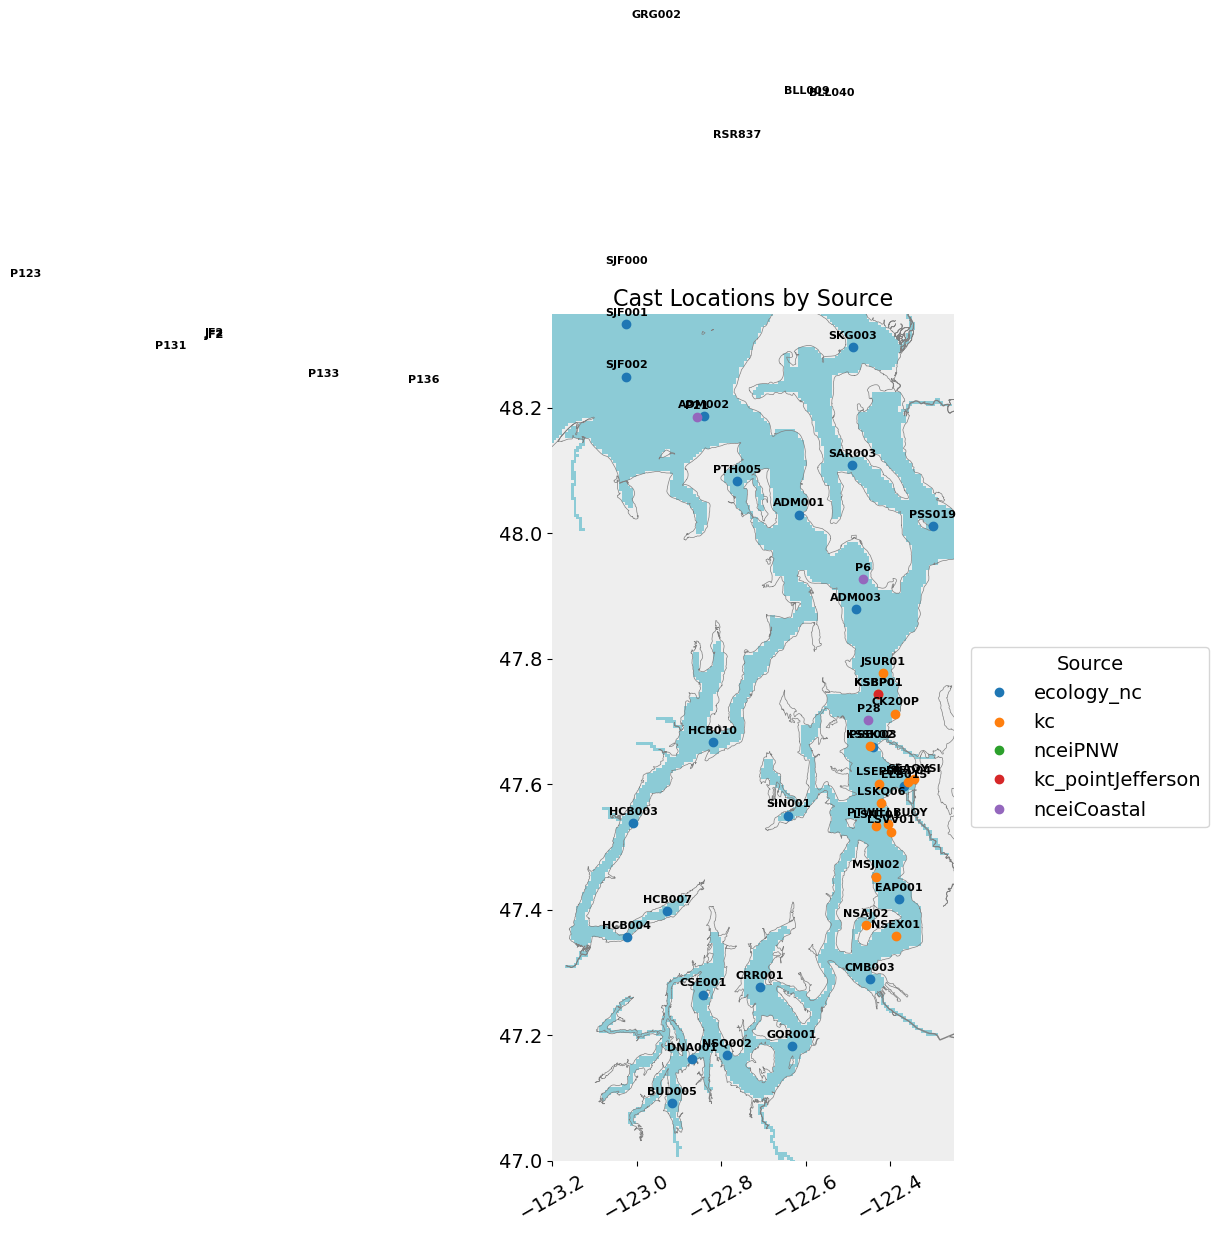

In [52]:
# create map

# Puget Sound only
# lat_low = 46.95
# lat_high = 48.95
# lon_low = -123.3
# lon_high = -122.1

# zoomed in
lat_low = 47.00
lat_high = 48.35
lon_low = -123.2
lon_high = -122.25

ds = xr.open_dataset('../../LO_data/grids/cas7/grid.nc')
z = -ds.h.values
mask_rho = np.transpose(ds.mask_rho.values)
lon = ds.lon_rho.values
lat = ds.lat_rho.values

plon, plat = pfun.get_plon_plat(lon, lat)

zm = z.copy()
zm[np.transpose(mask_rho) == 0] = np.nan
zm[np.transpose(mask_rho) != 0] = -1

# --- colors by source ---
sources = stn_df['source'].unique()
colors = dict(zip(sources, plt.cm.tab10(range(len(sources)))))

pfun.start_plot(figsize=(6,11))
fig = plt.gcf()
ax = fig.add_subplot(1,1,1)
plt.subplots_adjust(wspace=0, hspace=0.1)

# Map background
ax.add_patch(Rectangle((lon_low, lat_low),
                       lon_high-lon_low,
                       lat_high-lat_low,
                       facecolor='#EEEEEE'))

plt.pcolormesh(plon, plat, zm,
               vmin=-5, vmax=0,
               cmap=cmocean.cm.ice)

pfun.add_coast(ax, color='gray')
ax.axis([lon_low, lon_high, lat_low, lat_high])
pfun.dar(ax)

# --- plot stations by source ---
for src in sources:
    sub = stn_df[stn_df['source'] == src]

    ax.plot(sub['lon'], sub['lat'],
            linestyle='none',
            marker='o',
            color=colors[src],
            label=src)

    # labels
    for _, row in sub.iterrows():
        ax.text(row['lon'], row['lat'] + 0.01,
                row['name'],
                va='bottom', ha='center',
                fontsize=8, fontweight='bold')

ax.legend(title='Source', loc='center left', bbox_to_anchor=(1.02, 0.5))

ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30)

for border in ['top','right','bottom','left']:
    ax.spines[border].set_visible(False)

plt.title('Cast Locations by Source', fontsize=16)
fig.tight_layout()
plt.show()
#plt.savefig(out_dir / 'cast_locations_by_source.png', bbox_inches='tight')